# Example: Auto-Trading in a Network of Connected Autonomous Agents
In this example, we simulate a network of autonomous trading agents that observe expert traders using [technical analysis](https://en.wikipedia.org/wiki/Technical_analysis) to establish their state. Expert technical traders monitor market price trends, and non-expert trading agents observe the actions of the technical traders. We use `1-min` aggregate data of the [`QQQ` ETF year to date in 2024](https://oneminutedata.com/free-intraday-data) as the trading instrument.

> __Learning Objectives:__
> 
> By the end of this example, you will be able to:
> * __Compute simple moving average trade signals:__ Calculate the simple moving average of the typical price, develop a decision boundary with a buffer zone, and formulate a trading policy for edge agents based on price comparisons.
> * __Build custom totalistic Wolfram policy models:__ Manually construct agent policies that map neighborhood configurations to actions, compute rule indices from base-3 representations, and verify policy consistency.
> * __Simulate network dynamics with updating edge agents:__ Initialize agent states, precompute edge agent dynamics using the decision boundary, and run the network simulation to observe how trading signals propagate through connected agents.

Let's get started!
___

## Setup, Data, and Prerequisites
First, we set up the computational environment by including the `Include.jl` file and loading any needed resources.

> __Include:__ The [`include(...)` command](https://docs.julialang.org/en/v1/base/base/#include) evaluates the contents of the input source file, `Include.jl`, in the notebook's global scope. The `Include.jl` file sets paths, loads required external packages, etc. For additional information on functions and types used in this material, see the [Julia programming language documentation](https://docs.julialang.org/en/v1/). 

Let's set up our code environment:

In [3]:
include("Include.jl");

For additional information on functions and types used in this material, see the [Julia programming language documentation](https://docs.julialang.org/en/v1/) and the [VLQuantitativeFinancePackage.jl documentation](https://github.com/varnerlab/VLQuantitativeFinancePackage.jl).

### Data
The 1-minute aggregate `QQQ` data used in this example (YTD for the `2024` trading year) was downloaded from [oneminutedata.com](https://oneminutedata.com). The `QQQ` dataset, stored as a [comma-separated value (CSV) file](https://en.wikipedia.org/wiki/Comma-separated_values), is loaded using [the read method exported by the CSV.jl package](https://github.com/JuliaData/CSV.jl) as a [DataFrame instance](https://github.com/JuliaData/DataFrames.jl). 

We save the `QQQ` data in the `share_price_data_df::DataFrame` variable:

In [6]:
share_price_data_df = CSV.read(joinpath(_PATH_TO_DATA, "QQQ-OHLC-1-min-aggregate-2024.csv"), DataFrame);

Next, compute the [typical price](https://en.wikipedia.org/wiki/Typical_price) using [the `typicalprice(...)` function](https://varnerlab.github.io/VLQuantitativeFinancePackage.jl/dev/equity/#VLQuantitativeFinancePackage.typicalprice) for the `share_price_data_df::DataFrame`. We save the typical price (defined as `(h+l+c)/3`) in the `typical_price_array::Array{Float64,1}` array:

In [8]:
typical_price_array = typicalprice(share_price_data_df);

Next, augment the `share_price_data_df::DataFrame` to include the `typical_price_array::Array{Float64,1}` array. We store this data in the `:typicalprice::Symbol` column:

> __What is the `:` about in `:typicalprice`?__ The `:` prefix indicates we use a [Julia Symbol type](https://docs.julialang.org/en/v1/base/base/#Core.Symbol) for this data column. The columns of a [DataFrame instance](https://github.com/JuliaData/DataFrames.jl) are [Julia Symbols](https://docs.julialang.org/en/v1/base/base/#Core.Symbol), which are similar to Strings but with some differences. [Check out the docs here!](https://docs.julialang.org/en/v1/manual/metaprogramming/#Symbols)

In [10]:
share_price_data_df[:,:typicalprice] = typical_price_array; # now the dataframe has the typical price data (h+l+c)/3

### Constants and Parameters
Let's define some constants and parameters that we will use in this example. See the comment lines next to each variable for a description of its purpose, units, and permissible values:

In [12]:
number_of_trading_periods = length(typical_price_array); # how many minutes of 2024 data do we have?
start_index = 60;  # index to start viewing the data. This value needs to >= 1
stop_index = 1560; # index where we stop view the data. This value needs to be <= to number_of_trading_periods
view_range = range(start_index, stop = 1560, step = 1) |> collect; # view_range is the range we use to look at (simulate) the data
number_of_colors = 3; # each the number of colors, i.e., the number of possible states for each agent. 
radius = 4; # size of the neighborhood an agent looks at. DO NOT CHANGE
number_of_rows = 2^8; # number of rows in the 2D agent grid. Default: 256. Larger values will **slow down** the computation below
number_of_columns = 2^8; # number of cols in the 2D agent grid. Default: 256. Larger values will **slow down** the computation below
number_of_agents = number_of_rows*number_of_columns; # the number of agents in the grid
middle = (number_of_rows / 2) |> Int; # the index of the middle agent (we have a square grid by default, so middle x = middle y)

### Edge Cells
The `edge_coordinate_dictionary::Dict{Int64, Tuple{Int, Int64}}` dictionary holds information about the location and index of the active edge cells. These edge cells watch the external world and use a decision rule (developed below) to adjust their state. The keys of `edge_coordinate_dictionary` are the edge cell indexes, while the values are the `(i,j)` coordinates of the edge cell in our grid world. 

> __Note:__ In the default implementation, we have three active edge cells: the top middle, left middle, and bottom middle cell. The right middle cell is inactive, generating potentially non-symmetric patterns in the grid-world.

In [14]:
edge_coordinate_dictionary = Dict{Int64, Tuple{Int,Int64}}();
counter = 1;
for row ∈ 1:number_of_rows
    for col ∈ 1:number_of_columns

        if (row == 1 && col == middle)
            edge_coordinate_dictionary[counter] = (row,col);
            counter += 1;
        elseif (row == number_of_rows && col == middle)
            edge_coordinate_dictionary[counter] = (row,col);
            counter += 1;
        elseif (row == middle && col == 1)
            edge_coordinate_dictionary[counter] = (row,col);
            counter += 1;
        end
    end
end
edge_coordinate_dictionary

Dict{Int64, Tuple{Int64, Int64}} with 3 entries:
  2 => (128, 1)
  3 => (256, 128)
  1 => (1, 128)

In [15]:
number_of_edge_cells = length(edge_coordinate_dictionary);

### Color Dictionary
Construct the `my_color_dictionary::Dict{Int64, RGB}` dictionary, which maps the agent state values, e.g., $s\in\left\{0,1,2\right\}$ for a `number_of_colors = 3` system, to an [RGB color type exported by the Colors.jl package](https://github.com/JuliaGraphics/Colors.jl). 

Use the [`colorant` shortcut syntax exported by Colors.jl](https://juliagraphics.github.io/Colors.jl/stable/constructionandconversion/#Color-Parsing) to create instances of [named colors provided by Colors.jl](https://juliagraphics.github.io/Colors.jl/stable/namedcolors/). By default, we map: buy state (`s = 0`) to `lightgreen`, hold state (`s = 1`) to `gray95`, and sell state (`s = 2`) to `red`:

In [17]:
my_color_dictionary = Dict{Int64, RGB}();
my_color_dictionary[0] = colorant"lightgreen";  # 0: buy state
my_color_dictionary[1] = colorant"gray95";      # 1: hold state
my_color_dictionary[2] = colorant"red";         # 2: sell state

___

## Task 1: Compute Simple Moving Average Trade Signal Trajectory
In this task, we compute the simple moving average of the typical price of `QQQ` and develop a decision boundary for trading policy. We use an [incremental simple moving average](https://en.wikipedia.org/wiki/Moving_average) where the average price is updated with new data as the algorithm marches through time.

Let the typical price in period $\tau$ be given by $S_{\tau}$ (units: `USD/share`) and the moving average of the typical price at time $\tau$ be given by $\hat{S}_{\tau}$ (units: `USD/share`):
$$
\begin{equation}
\hat{S}_{\tau} = \hat{S}_{\tau - 1} + \alpha(\tau)\cdot\left(S_{\tau} - \hat{S}_{\tau - 1}\right)
\end{equation}
$$
where $\alpha(\tau)$ is the learning function. The learning function controls how much new information is included in the update between $(\tau-1)\rightarrow\tau$. 

> __Parameters:__ A simple moving average computed over a time window of length $\mathcal{L}\geq{1}$ has a learning function given by $\alpha(\tau) = \mathcal{L}^{-1}$. As the window length increases, i.e., $\mathcal{L}\rightarrow\infty$, the simple moving average learning rate goes to zero $\alpha(\tau) \rightarrow{0}$.

Let's specify a constant value for the learning function such that $0<\alpha(\tau)<1$ and save it in the `α::Float64` variable (units: `1/min`):

In [19]:
α = (1/60); # students can update this! what happens if we recompute the mvap_array with diff values of α?

Using the incremental update expression above, let's populate the `mtypical_price_array::Array{Float64,1}` array. First, we initialize the average `mtypicalprice` series with the `typicalprice` value. Thus, at the first time step (array index `1`), the `mtypicalprice = typicalprice`. Then, we compute the moving average using [a `for-loop`](https://docs.julialang.org/en/v1/base/base/#for):

In [21]:
mtypical_price_array = Array{Float64,1}(undef, number_of_trading_periods);
mtypical_price_array[1] = typical_price_array[1]; 

for i ∈ 2:number_of_trading_periods
    previous_mtp = mtypical_price_array[i-1];
    current_tp = typical_price_array[i];
    mtypical_price_array[i] = previous_mtp + α*(current_tp - previous_mtp);
end

#### Visualize the Moving Typical Price
Unhide the code block below to see how we plotted the actual and moving typical price for `1-min` aggregates of `QQQ`.

> __What should we expect to see?__ The `typicalprice` for `QQQ` is shown in the blue line, while the moving average of the typical price (mtp) is shown by the red line. The mtp is a smoothed and lagged version of the `typicalprice` with high-frequency information removed. The $\alpha(\tau)$ parameter controls the inclusion of fast or slow dynamics.

> __What is the significance of $\alpha(\tau)$?__ The parameter $\alpha(\tau)$ represents a time constant measured in units of `1/min`. When $\alpha(\tau)$ is large, the mtp trajectory includes high-frequency data. When $\alpha(\tau)$ is small, only slow dynamics or low-frequency information is retained.

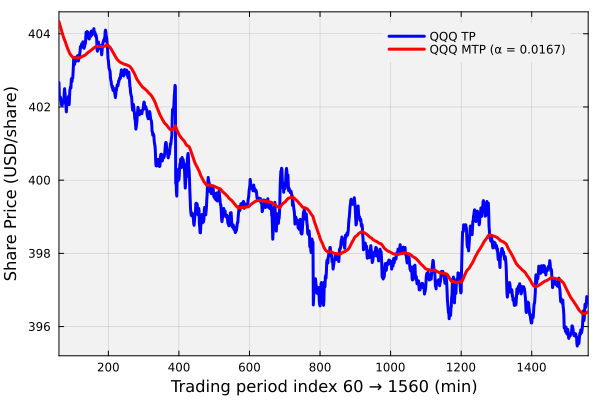

In [23]:
let
    q = plot(bg="gray95", background_color_outside="white", framestyle = :box, fg_legend = :transparent, legend=:topright);
    plot(q, view_range, typical_price_array[view_range],c=:blue, xlims=(first(view_range), last(view_range)), lw=3, label="QQQ TP")
    plot!(view_range, mtypical_price_array[view_range], c=:red, lw=3, label="QQQ MTP (α = $(round(α, digits=4)))")
    xlabel!("Trading period index $(first(view_range)) → $(last(view_range)) (min)", fontsize=18)
    ylabel!("Share Price (USD/share)", fontsize= 18);
end

### Develop a Decision Boundary
The moving average typical price (mtp) gives us a reference trajectory to use as a decision boundary.

> __Hypothesis:__ If `typicalprice` < `mtypicalprice`, we buy shares as we expect `QQQ` to be oversold and the price will revert to the `mtypicalprice` value. If `typicalprice` > `mtypicalprice`, we sell shares as we expect `QQQ` is overbought and the price will drop to the mtp.

However, let's add a buffer of size $\pm\,\beta\cdot\sigma$ around the `mtypicalprice` trajectory in which we hold. The multiplier $\beta$ is a user-adjustable hyperparameter, while $\sigma$ is the standard deviation of the `mtypicalprice`. This is [similar to Bollinger Bands](https://en.wikipedia.org/wiki/Bollinger_Bands).

#### Calculate the Decision Boundary Standard Deviation
We propose an update rule for the standard deviation of the form:
$$
\begin{equation}
\hat{\sigma}_{\tau} = \hat{\sigma}_{\tau - 1} + \alpha(\tau)\cdot\left(\epsilon_{\tau} - \hat{\sigma}_{\tau - 1}\right)
\end{equation}
$$
where $\alpha(\tau)$ is the learning function, and $\epsilon_{\tau}$ is the 1-step standard deviation:
$$
\begin{equation}
\epsilon_{\tau} = \sqrt{\left(S_{\tau} - \hat{S}_{\tau}\right)^2}
\end{equation}
$$
The $S_{\tau}$ value denotes the typical price at time $\tau$, while the $\hat{S}_{\tau}$ term denotes the moving average typical price at time $\tau$. The $\epsilon_{\tau}$ term measures the residual between the typical price and the mtp. 

We initialize the first value of this series to zero since we have complete knowledge of the average price at index `1` because `tp = mtp` at index `1`, thus $\hat{\sigma}_{1} = 0$:

In [26]:
decision_boundary_array = Array{Float64,1}(undef, number_of_trading_periods);
decision_boundary_array[1] = 0.0;
for i ∈ 2:(number_of_trading_periods)
    previous_decision_boundary = decision_boundary_array[i-1];
    ϵ = (typical_price_array[i] - mtypical_price_array[i])^2 |> x -> sqrt(x);
    decision_boundary_array[i] = previous_decision_boundary + α*(ϵ - previous_decision_boundary);
end

#### Visualize the Decision Boundary
Let's plot the `decision_boundary_array` along with the typical price and mtp trajectories. First, select a value for the multiplier hyperparameter $\beta$:

> __What does $\beta$ do?__ This user-adjustable parameter controls the width of the hold band. The $\beta$ parameter is similar to a [z-value in statistics](https://en.wikipedia.org/wiki/Standard_score). Large values of $\beta$ lead to a wide hold band where only extreme events generate buy or sell signals. Small $\beta$ values allow more buy and sell moves. Setting `β = 1` means approximately 30% of price moves generate buy or sell signals.

In [28]:
β = 1.0;

Unhide the code block below to reveal the code for plotting the typical price, the mtp, and the decision boundary trajectory.

> __What should we expect to see?__ The typical price is shown by the blue line, the mtp is shown in the red line, and the $\pm\,\beta\cdot\hat{\sigma}_{\tau}$ region around the mtp is shown in the gray shaded region. Values of typical price inside the gray region indicate the agent is in the hold state. Typical price below the gray region indicates the buy state. Typical price above the gray region indicates the sell state.

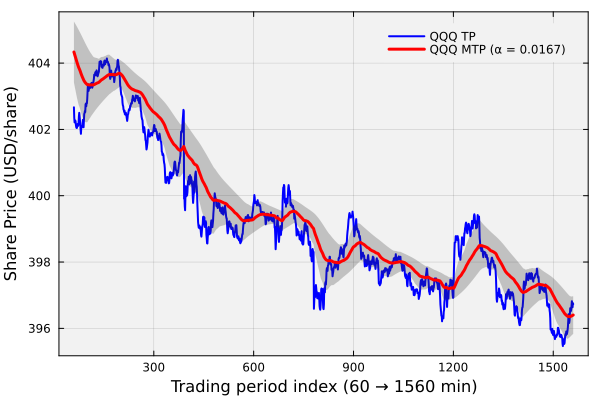

In [30]:
let    
    q = plot(bg="gray95", background_color_outside="white", framestyle = :box, fg_legend = :transparent, legend=:topright);
    plot(q, view_range, typical_price_array[view_range],c=:blue, lw=2, label = "QQQ TP")

    UB = mtypical_price_array[view_range] + β*decision_boundary_array[view_range];
    LB = mtypical_price_array[view_range] - β*decision_boundary_array[view_range];
    plot!(view_range, mtypical_price_array[view_range], fillrange = UB, label="", alpha=0.25, c=:gray20)
    plot!(view_range, mtypical_price_array[view_range], fillrange = LB, label="", alpha=0.25, c=:gray20)
    plot!(view_range, mtypical_price_array[view_range], c=:red, lw = 3, label="QQQ MTP (α = $(round(α, digits=4)))")
    xlabel!("Trading period index ($(first(view_range)) → $(last(view_range)) min)", fontsize=18)
    ylabel!("Share Price (USD/share)", fontsize= 18);
end

___

## Task 2: Formulate Interior Agent Decision Policies 
In this task, we create interior agent policies. Agents positioned at the edges of a grid world use the mtp decision boundary to determine whether to buy, hold, or sell. Agents inside the grid observe the actions of the edge agents and make their own decisions based on their individual policies.

We manually set up the policy so that we can adjust the choices our agents make based on their environment.

### Build a Custom Totalistic Wolfram Policy Model
In the worked example for this module, we created an instance of the [`MyTwoDimensionalTotalisticWolframRuleModel` type](https://varnerlab.github.io/VLQuantitativeFinancePackage.jl/dev/RL/#VLQuantitativeFinancePackage.MyTwoDimensionalTotalisticWolframRuleModel). We selected a value for `rule_index::Int64` and then constructed the model instance. The [`build(...)` method](https://varnerlab.github.io/VLQuantitativeFinancePackage.jl/dev/RL/#VLQuantitativeFinancePackage.build-Tuple{Type{MyTwoDimensionalTotalisticWolframRuleModel},%20NamedTuple}) generated the policy corresponding to `rule_index::Int64`.

> __Approach:__ Suppose we use customizable logic to compute a value for `rule_index::Int64` based on what we want our agent to do in different scenarios. Then, we know exactly what behavior to expect from our trading agent. Once we have a value for `rule_index::Int64`, we construct [a rule model instance](https://varnerlab.github.io/VLQuantitativeFinancePackage.jl/dev/RL/#VLQuantitativeFinancePackage.MyTwoDimensionalTotalisticWolframRuleModel).

Let's start by setting some constant values:

In [33]:
number_of_colors = 3; # the number of colors, i.e., the number of possible states for each agent. 
radius = 4; # size of the neighborhood an agent looks at. DO NOT CHANGE

The total number of neighborhood configurations, numbered starting from `0`, is given by `(number_of_colors - 1)⋅radius + 1`. We enumerate these configurations using the [Julia `range(...)` method](https://docs.julialang.org/en/v1/base/math/#Base.range) combined with [the `collect(...)` method](https://docs.julialang.org/en/v1/base/collections/#Base.collect-Tuple{Type,%20Any}). We save the list of possible totalistic configurations in the `neighborhood_configuration_array::Array{Float64,1}` array:

In [35]:
neighborhood_configuration_array = range(0, stop = (number_of_colors - 1), step = (1/radius)) |> collect

9-element Vector{Float64}:
 0.0
 0.25
 0.5
 0.75
 1.0
 1.25
 1.5
 1.75
 2.0

#### Check: Is the Total Number of Configurations Correct?
There should be `(number_of_colors - 1)⋅radius + 1` configurations. Let's check this value against the length of the `neighborhood_configuration_array::Array{Float64,1}` array using the [Julia @assert macro](https://docs.julialang.org/en/v1/base/base/#Base.@assert):

In [37]:
@assert length(neighborhood_configuration_array) == (number_of_colors - 1)*radius + 1

Now that we know the `neighborhood_configuration_array::Array{Float64,1}` array, we can map these configurations to possible agent states. Each agent is influenced by `radius::Int64` neighbors, where each neighbor is in state $s\in{0,1,2}$ or `{0 = buy, 1 = hold, 2 = sell}` during each turn of the simulation:

In [39]:
# 222110002
internal_agent_policy = Dict{Int64, Int64}()
internal_agent_policy[0] = 2; # c: 0 => 0.00; 4/4 of my neighbors are in the buy state => sell
internal_agent_policy[1] = 0; # c: 1 => 0.25; 3/4 of my neighbors are in the buy state, 1 neighbor is holding => buy
internal_agent_policy[2] = 0; # c: 2 => 0.50; 2/4 of my neighbors are in the buy state, 2 neighbors are holding (or 1 is sell?) => buy
internal_agent_policy[3] = 0; # c: 3 => 0.75; 1/4 of my neighbors are in the buy state, 3 neighbors are holding => buy
internal_agent_policy[4] = 1; # c: 4 => 1.00; 4/4 of my neighbors are holding => hold
internal_agent_policy[5] = 1; # c: 5 => 1.25; 3/4 of my neighbors are holding, 1 neighbor is selling => hold
internal_agent_policy[6] = 2; # c: 6 => 1.50; 2/4 of my neighbors are holding, 2 neighbors are selling => sell
internal_agent_policy[7] = 2; # c: 7 => 1.75; 1/4 of my neighbors are holding, 3 neighbors are selling => sell
internal_agent_policy[8] = 2; # c: 8 => 2.00; 4/4 of my neighbors are selling  => buy

We have manually constructed a policy using reasonable logic; we watch what our neighbors are doing and copy them for the most part. This approach is related to [imitation learning](https://en.wikipedia.org/wiki/Imitative_learning), where agents copy the actions of perceived experts. However, we still need to encode this policy as a `rule_index::Int64` value.

> __Policy enumeration__: Policies can be enumerated by counting [in base `b`](https://en.wikipedia.org/wiki/Numeral_system#:~:text=In%20a%20positional%20base%20b,in%20the%20figure%20is%20used.), where `b = number_of_colors`. The base `b` representation uses the digit set:
>
> $$\mathcal{D}_{b} = \left\{0, 1, \dots, (b - 1)\right\}$$
>
> For any $n\geq{0}$ and $b\geq{2}$, there is a string of k-digits $\left(a_{k-1}\,a_{k-2},\dots,a_{2}\,a_{1}a_{0}\right)_{b}$ where $a_{i}\in\mathcal{D}_{b}$ such that the base-10 representation is:
>
> $$n = \sum_{j=0}^{k-1}a_{j}\cdot{b^{j}}$$
>
> where $a_{j}$ denotes the digit in position $j$, `b` denotes the base, and `k = number_of_colors`.

Our manual policy can be written as `(022110002)₃` in base `b = 3`. We need the base-10 representation of `(022110002)₃`; let's write some code to compute this conversion:

In [41]:
number_of_configurations = (number_of_colors - 1)*radius + 1;
rule_index = [internal_agent_policy[i]*(number_of_colors^(i)) for i ∈ 0:(number_of_configurations - 1)] |> sum
println("The rule_index for our *expert* manual policy = $(rule_index)")

The rule_index for our *expert* manual policy = 19280


Create the rule model by passing [`MyTwoDimensionalTotalisticWolframRuleModel`](https://varnerlab.github.io/VLQuantitativeFinancePackage.jl/dev/RL/#VLQuantitativeFinancePackage.MyTwoDimensionalTotalisticWolframRuleModel) and argument data organized in a [Julia NamedTuple instance](https://docs.julialang.org/en/v1/base/base/#Core.NamedTuple) to the [`build(...)` method](https://varnerlab.github.io/VLQuantitativeFinancePackage.jl/dev/RL/#VLQuantitativeFinancePackage.build-Tuple{Type{MyTwoDimensionalTotalisticWolframRuleModel},%20NamedTuple}). This type requires a value for the `rule_index::Int64`, the `colors::Int64` field and the `radius::Int64`:

In [43]:
policy_model = build(MyTwoDimensionalTotalisticWolframRuleModel, (
    index = rule_index,
    colors = number_of_colors,
    radius = radius,
));

#### Check: Compare the manual and computed policies
Compare the `rule::Dict{Int64, Int64}` field on the `policy_model::MyTwoDimensionalTotalisticWolframRuleModel` instance with our manual policy. If all is correct, the automatically generated rule should have the same entries as the `internal_agent_policy::Dict{Int64, Int64}` dictionary:

> __Strategy__: Iterate through each `(k,v)` pair of the `internal_agent_policy::Dict{Int64, Int64}` dictionary and compare the values with those in the `rule::Dict{Int64, Int64}` dictionary of the `policy_model::MyTwoDimensionalTotalisticWolframRuleModel` instance using [the equality `==` operator](https://docs.julialang.org/en/v1/manual/missing/#Equality-and-Comparison-Operators). If values are _not equal_, an [AssertionError is thrown](https://docs.julialang.org/en/v1/base/base/#Core.AssertionError).

In [45]:
R = policy_model.rule
for (k,v) ∈ internal_agent_policy
    @assert v == R[k]
end

If no `AssertionError` is thrown, we can proceed to the next task.

___

## Task 3: Simulate the Dynamics of a Network of Trading Agents
In this task, we'll use the decision boundary from Task 1 and the internal agent policy from Task 2 to construct a simulation of how a network of autonomous, connected trading agents behaves over time.

> __Approach__: Unlike the worked example where boundary agent states were fixed, in this case, our boundary agents change state with each turn. We'll set up the initial state of all agents, precompute the dynamics of edge agents (to speed up and simplify the simulation), and then run the network simulation to create a movie and observe the impact of our implemented policy.

### Setup the initial state of the agents
Set up the `initialstate::Array{Int64,2}` array, which is a `number_of_rows` $\times$ `number_of_cols` array holding the initial state of each agent at `t = 0`. Each element is the state $s_{ij}$ for the agent at element `(i,j)`, where $s_{ij}\in$`{0...number_of_colors-1}`:

> __Default state__: Let the default `initialstate::Array{Int64,2}` array have `1's` everywhere, i.e., everyone (including edge agents) is initially in the `hold` state. Declare the `initialstate::Array{Int64,2}` array and use [the Julia `fill!(...)` method](https://docs.julialang.org/en/v1/base/arrays/#Base.fill!) to insert `1's` into each entry.
>
> __Challenge__: Can you declare the `initialstate::Array{Int64,2}` array and fill it with `1's` in a single line using [the Julia `|>` pipe composition operator](https://docs.julialang.org/en/v1/manual/functions/#Function-composition-and-piping)?

In [50]:
initialstate = Array{Int64,2}(undef, number_of_rows, number_of_columns) |> X -> fill!(X,1); # nice ...

### Precompute edge agent dynamics
To speed up and simplify the simulation, we'll precompute the dynamics of the edge cells. These cells use the `QQQ` mtp decision boundary to compute their next state instead of a neighborhood of agents. The precomputed edge states are saved in the `edge_cell_next_state_dictionary::Dict{Int64, Array{Int64,1}}` dictionary:

> __Strategy__: First, allocate an empty `edge_cell_next_state_dictionary::Dict{Int64, Array{Int64,1}}` dictionary. Then, using the [`eachindex(...)` iteration pattern](https://docs.julialang.org/en/v1/base/arrays/#Base.eachindex), iterate through each turn in the `view_range::Array{Int64,1}` array and compute a decision for the next state by comparing the `tp` with the decision boundary computed above.

In [52]:
edge_cell_next_state_dictionary = Dict{Int64, Array{Int64,1}}();
for i ∈ eachindex(view_range)
    t = view_range[i];

    # setup decision range -
    UB = mtypical_price_array[t] + β*decision_boundary_array[t];
    LB = mtypical_price_array[t] - β*decision_boundary_array[t];
    Sᵢ = typical_price_array[t];

    next_state = nothing;
    if (LB ≤ Sᵢ ≤ UB)
        next_state = 1; # We are in the gray region => hold
    elseif (Sᵢ > UB)
        next_state = 2; # We are beyond the upper bound => sell
    else
        next_state = 0; # We are below the lower bound => buy
    end
    
    # iterate through each edge cell and update its next state value -
    next_state_array = Array{Int64,1}(undef, number_of_edge_cells);
    for i ∈ 1:number_of_edge_cells
        next_state_array[i] = next_state;
    end
    edge_cell_next_state_dictionary[t] = next_state_array
end

#### Visualize the edge dynamics
`Unhide` the code block below to see the edge agents' buy, hold, and sell dynamics. These agents use the `mtp-decision-rule` constructed above to set their state. We display these cells as a row vector, with edge cell indices computed and stored in the `edge_coordinate_dictionary::Dict{Int64, Tuple{Int, Int64}}` dictionary:

> __Note__: All edge cells follow the same rule, so they make the same decisions and are in the same state. An interesting extension would be to construct a system where each edge agent has its own $\alpha,\beta$ parameters, creating potentially unique decision boundaries. Alternatively, students could inject randomness by adding "mistakes" into the state, i.e., the decision rule says buy, but the agent sells by mistake.
>
> Given the default `view_range::Array{Int64,1}` array, some interesting cells to view are: `i = 687` (buy state), `i = 700` (hold state), and `i = 1200` (sell state). With different values of $\alpha$ and $\beta$, the dynamics will vary, but they correspond to the decision boundary plot above.

In [54]:
let
    time_index_to_view = 687; # this is the view range index, i.e., it starts with start_index. So i = 1 => start_index in raw time
    t = view_range[time_index_to_view]; # set 
    
    next_state_array = edge_cell_next_state_dictionary[t]
    new_display_frame = Array{RGB,2}(undef, 1, number_of_edge_cells);
    for j ∈ 1:number_of_edge_cells
        new_display_frame[1,j] = next_state_array[j] |> s -> my_color_dictionary[s];
    end
    display(new_display_frame) 
end

### Run the simulation with updating edge agents
Simulate the evolution of expert technical agents and agents following our custom rule described in the `policy_model::MyTwoDimensionalTotalisticWolframRuleModel` instance [using the `solve(...)` method exported by `VLQuantitativeFinancePackage.jl`](https://varnerlab.github.io/VLQuantitativeFinancePackage.jl/dev/RL/#VLQuantitativeFinancePackage.solve-Tuple{MyTwoDimensionalTotalisticWolframRuleModel,%20Matrix{Int64}}):

> __Strategy__: The [`solve(...)` method](https://varnerlab.github.io/VLQuantitativeFinancePackage.jl/dev/RL/#VLQuantitativeFinancePackage.solve-Tuple{MyTwoDimensionalTotalisticWolframRuleModel,%20Matrix{Int64}}) takes three arguments: the `policy_model::MyTwoDimensionalTotalisticWolframRuleModel` instance, the `initialstate::Array{Int64,2}` of the population of agents, and the number of turns to simulate in the `steps::Int64` argument. Unlike the example, we take `1-step` forward each turn, then boundary agents get updated using the `mtp decision rule` to set their state. The updated frame becomes the initial condition for the next step.
>
> The [`solve(...)` method](https://varnerlab.github.io/VLQuantitativeFinancePackage.jl/dev/RL/#VLQuantitativeFinancePackage.solve-Tuple{MyTwoDimensionalTotalisticWolframRuleModel,%20Matrix{Int64}}) returns the `frames::Dict{Int64, Array{Int64,2}}` dictionary holding the state of the system, encoded as a `number_of_rows` $\times$ `number_of_cols` array with agent state $s_{ij}$ values for each turn, starting at `0` up to `1`. We copy the frame at the end of the single step, which becomes the initial state for the next step after updating edge cell states.

In [56]:
simulation_dictionary = Dict{Int64,Array{Int64,2}}();
previous_state_array = copy(initialstate);
for i ∈ eachindex(view_range)
    t = view_range[i];

    # update edge cells in the previous state -
    edge_cell_state_array = edge_cell_next_state_dictionary[t];
    for j ∈ 1:number_of_edge_cells
        coordinate = edge_coordinate_dictionary[j];
        previous_state_array[coordinate[1],coordinate[2]] = edge_cell_state_array[j];
    end

    # run the simulated 1-turn
    frames = solve(policy_model, previous_state_array, steps = 1);
    
    # get the frame -
    previous_state_array = copy(frames[1]);
    simulation_dictionary[t] = frames[1];
end

#### Visualize the network of agents
Visualize the data in the `simulation_dictionary::Dict{Int64,Array{Int64,2}}` variable [using the `display(...)` method exported by Images.jl](https://github.com/JuliaImages/Images.jl).

`Unhide` and `uncomment` the code block below to play a movie of the simulation data. This code iterates over the `view_range::Array{Int64,1}` array containing turn indices. For each turn, the data frame is accessed from `simulation_dictionary::Dict{Int64, Array{Int64,2}}`, recolored using `my_color_dictionary::Dict{Int64, RGB}`, and displayed using [the `display(...)` method from Images.jl](https://github.com/JuliaImages/Images.jl):

> __Observations__: Initially, all agents are in the hold state (white). The edge cells, using the `mtp-decision-rule`, eventually initiate a transition that propagates through the network until an autonomous random pattern of hold, buy, and sell activity emerges (assuming policy `(022110002)₃` or `rule-index = 6158`).
>
> Another interesting rule is `(222110002)₃` (`rule_index = 19280`), which has similar dynamics but produces temporary bursts of sell-state activity throughout the grid world. These bursts persist for a few turns and then disappear.

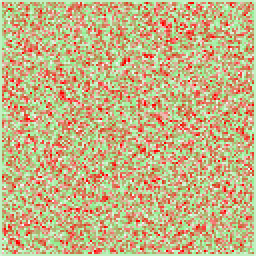

t = 1560 min


┌ Warning: Output swatches are reduced due to the large size (256×256).
│ Load the ImageShow package for large images.
└ @ Colors ~/.julia/packages/Colors/VFEJ1/src/display.jl:159


In [59]:
for i ∈ eachindex(view_range)
    t = view_range[i];
    myframe = simulation_dictionary[t];
    new_display_frame = Array{RGB,2}(undef, number_of_rows, number_of_columns);
    for j ∈ 1:number_of_rows
        for k ∈ 1:number_of_columns
            new_display_frame[j,k] = myframe[j,k] |> s -> my_color_dictionary[s];
        end
    end
    display(new_display_frame)
    println("t = $(t) min")
    IJulia.clear_output(true)
end

## Summary
This example demonstrates how totalistic Wolfram rules can be applied to simulate network dynamics of connected autonomous trading agents in a grid-world environment.

> __Key Takeaways:__
>
> * __Moving Average and Decision Boundaries:__ We computed a moving typical price `mtp` and used it to define buy, hold, and sell regions based on standard deviation bands controlled by the parameters $\alpha$ and $\beta$.
> * __Totalistic Wolfram Rules:__ We developed an internal agent policy where agents make decisions based on the sum of their neighbors' states, encoded as a base-3 rule index that maps neighborhood configurations to agent actions.
> * __Network Dynamics:__ We simulated how edge agents (using the mtp-decision-rule) influence interior agents (using the Wolfram policy), creating emergent patterns of trading behavior that propagate through the network.
> * __Policy Exploration:__ Different rule indices produce different dynamics, from stable patterns to temporary bursts of activity, demonstrating the rich behavior possible with simple local rules.

By combining technical analysis concepts with cellular automaton dynamics, this framework provides a foundation for studying how information and trading signals propagate through networks of interacting agents.
___

## Disclaimer and Risks
__This content is offered solely for training and informational purposes__. No offer or solicitation to buy or sell securities or derivative products, or any investment or trading advice or strategy, is made, given, or endorsed by the teaching team.

__Trading involves risk__. Carefully review your financial situation before investing in securities, futures contracts, options, or commodity interests. Past performance, whether actual or indicated by historical tests of strategies, is no guarantee of future performance or success. Trading is generally inappropriate for someone with limited resources, limited investment or trading experience, or a low-risk tolerance. Only risk capital that is not required for living expenses should be used for trading.

__You are fully responsible for any investment or trading decisions you make__. Such decisions should be based solely on evaluating your financial circumstances, investment or trading objectives, risk tolerance, and liquidity needs.